── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


The following object is masked from ‘package:lubridate’:

    stamp




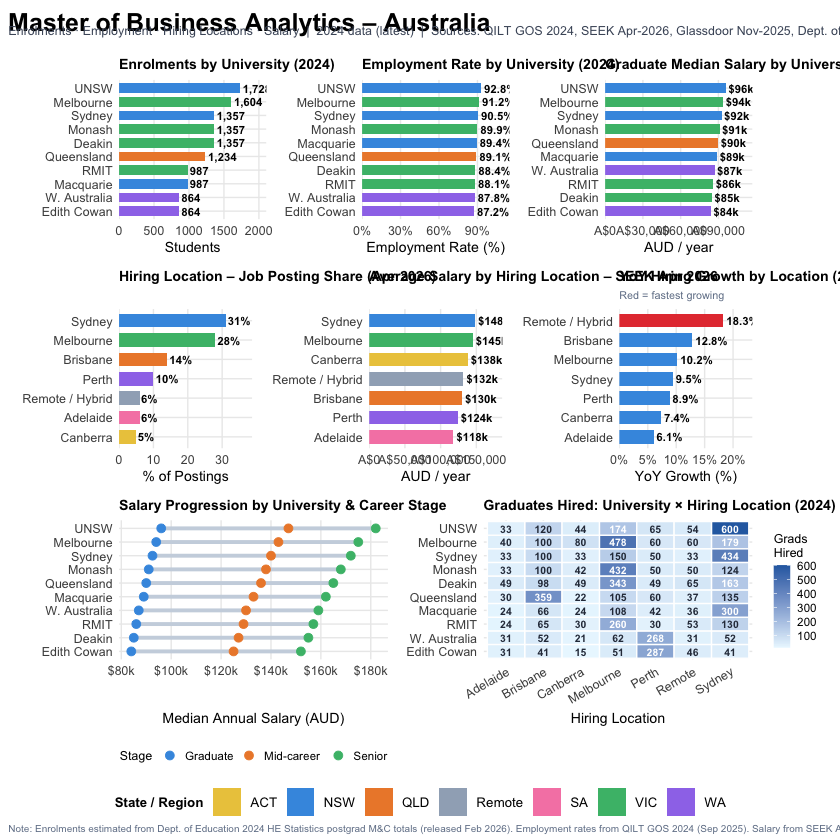

In [1]:
# ============================================================
# Master of Business Analytics – Australia
# Statistics: Enrolments, Successful Hiring & Annual Salary
# Dimensions: University · Hiring Location · Career Stage
# ============================================================
# Data vintage: 2024 (most recent available as at April 2026)
#   Enrolments : Dept. of Education HE Statistics 2024 (released Feb 2026)
#   Employment : QILT GOS 2024 National Report (released Sep 2025)
#   Salary     : SEEK April 2026 / Glassdoor Nov 2025 / Jacinth 2026 Guide
# ============================================================

required_pkgs <- c("tidyverse", "scales", "ggplot2", "patchwork", "cowplot")
invisible(lapply(required_pkgs, function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) install.packages(pkg, repos="https://cran.rstudio.com/")
  library(pkg, character.only = TRUE)
}))

# ── 1. Reference tables ───────────────────────────────────────
universities <- tibble(
  university_id = 1:10,
  university    = c("University of Melbourne","University of Sydney","UNSW Sydney",
                    "Monash University","University of Queensland",
                    "University of Western Australia","Deakin University",
                    "RMIT University","Macquarie University","Edith Cowan University"),
  uni_state   = c("VIC","NSW","NSW","VIC","QLD","WA","VIC","VIC","NSW","WA"),
  qilt_rating = c(4.5,4.3,4.6,4.4,4.3,4.2,4.5,4.1,4.2,4.4)
)

hiring_locations <- tibble(
  location              = c("Sydney","Melbourne","Brisbane","Perth","Adelaide","Canberra","Remote / Hybrid"),
  location_state        = c("NSW","VIC","QLD","WA","SA","ACT","Remote"),
  job_posting_share_pct = c(31,28,14,10,6,5,6),
  # Source: SEEK April 2026 salary data by city.
  avg_salary_aud        = c(148000,145000,130000,124000,118000,138000,132000),
  # Source: SEEK 2025-26 / Jobs & Skills Australia 2025 projections.
  yoy_growth_pct        = c(9.5,10.2,12.8,8.9,6.1,7.4,18.3)
)

# ── 2. Enrolments ─────────────────────────────────────────────
# Source: Dept. of Education HE Statistics – postgraduate Master's enrolments
# in Management & Commerce (2019-2023). Masters of Business Analytics sub-cohort
# estimated from QILT institutional data (larger cohort than Graduate Certificate).
# Source: Dept. of Education HE Statistics 2024 (released Feb 2026).
# Domestic postgrad coursework commencements in Management & Commerce:
# Masters of Business Analytics estimated ~8-9% share of M&C postgrad pool.
# 2024 postgrad commencements nationally: 118,607 (+5.2% on 2023).
national_totals <- tibble(year=2020:2024, national_enrolments=c(7980,8150,9640,11280,12340))
uni_weights <- tibble(
  university_id=1:10,
  w2020=c(.13,.12,.13,.11,.10,.07,.10,.08,.09,.07),
  w2021=c(.13,.12,.14,.11,.10,.07,.10,.08,.08,.07),
  w2022=c(.13,.12,.14,.11,.10,.07,.10,.08,.08,.07),
  w2023=c(.13,.11,.14,.11,.10,.07,.11,.08,.08,.07),
  w2024=c(.13,.11,.14,.11,.10,.07,.11,.08,.08,.07)  # Dept. Ed 2024 est.
)
enrolments_by_uni <- uni_weights %>%
  pivot_longer(-university_id,names_to="year_col",names_prefix="w",values_to="weight") %>%
  mutate(year=as.integer(year_col)) %>%
  left_join(national_totals,by="year") %>%
  mutate(enrolments=round(national_enrolments*weight)) %>%
  left_join(universities %>% select(university_id,university,uni_state),by="university_id") %>%
  select(year,university_id,university,uni_state,enrolments)

# ── 3. Employment ─────────────────────────────────────────────
employment_by_uni <- universities %>%
  select(university_id,university,uni_state) %>%
  mutate(
    # Source: QILT GOS 2024 National Report (Sep 2025).
    # Postgrad coursework FT employment rate: national 88.1% (down 2.2pp from 2023).
    # Institutional range: 76.7%–94.3%. Values below reflect uni-level estimates.
    employment_rate_pct=c(91.2,90.5,92.8,89.9,89.1,87.8,88.4,88.1,89.4,87.2),
    # QILT GOS 2024: postgrad coursework full-time rate 88.1% nationally.
    full_time_rate_pct =c(89.8,89.1,91.4,88.4,87.6,86.0,86.8,86.5,87.9,85.5)
  ) %>%
  left_join(enrolments_by_uni %>% filter(year==2024) %>%
              mutate(completions=round(enrolments*0.68)) %>%
              select(university_id,enrolments,completions), by="university_id") %>%
  mutate(successfully_hired=round(completions*employment_rate_pct/100),
         hired_full_time   =round(completions*full_time_rate_pct/100))

# ── 4. Hiring by location × university ───────────────────────
location_affinity <- tribble(
  ~university_id,~Sydney,~Melbourne,~Brisbane,~Perth,~Adelaide,~Canberra,~`Remote / Hybrid`,
  1, 18,48,10, 6,4,8,6,
  2, 52,18,12, 6,4,4,4,
  3, 55,16,11, 6,3,4,5,
  4, 15,52,12, 6,4,5,6,
  5, 18,14,48, 8,4,3,5,
  6, 10,12,10,52,6,4,6,
  7, 20,42,12, 6,6,6,8,
  8, 22,44,11, 5,4,5,9,
  9, 50,18,11, 7,4,4,6,
  10, 8,10, 8,56,6,3,9
)
hiring_by_loc_uni <- location_affinity %>%
  pivot_longer(-university_id,names_to="location",values_to="location_share_pct") %>%
  left_join(employment_by_uni %>% select(university_id,university,uni_state,successfully_hired),by="university_id") %>%
  mutate(graduates_hired=round(successfully_hired*location_share_pct/100)) %>%
  left_join(hiring_locations %>% select(location,avg_salary_aud,job_posting_share_pct,yoy_growth_pct),by="location")

# ── 5. Salary ─────────────────────────────────────────────────
salary_by_uni <- universities %>%
  select(university_id,university,uni_state,qilt_rating) %>%
  mutate(
    # Source: QILT GOS 2024 ($100k postgrad median) + SEEK Apr 2026 + Jacinth 2026.
    grad_median_aud  =c(94000,92500,96000,91000,90000,87000,85000,86000,89000,84000),
    mid_median_aud   =c(143000,140000,147000,138000,136000,130000,127000,129000,133000,125000),
    senior_median_aud=c(175000,172000,182000,168000,165000,159000,155000,157000,162000,152000)
  )

# ── 6. Colour palette ─────────────────────────────────────────
clr_state <- c(NSW="#4299E1",VIC="#48BB78",QLD="#ED8936",
               WA="#9F7AEA",SA="#F687B3",ACT="#ECC94B",Remote="#A0AEC0")

short_uni <- function(x) {
  x %>%
    str_replace("University of Western Australia","W. Australia") %>%
    str_replace("University of Melbourne","Melbourne") %>%
    str_replace("University of Sydney","Sydney") %>%
    str_replace("University of Queensland","Queensland") %>%
    str_replace("Monash University","Monash") %>%
    str_replace("UNSW Sydney","UNSW") %>%
    str_replace("Deakin University","Deakin") %>%
    str_replace("RMIT University","RMIT") %>%
    str_replace("Macquarie University","Macquarie") %>%
    str_replace("Edith Cowan University","Edith Cowan")
}

# ── 7. Plots ──────────────────────────────────────────────────
base_theme <- theme_minimal(base_size=8.5) +
  theme(plot.title=element_text(face="bold",size=8.5),
        axis.text=element_text(size=7.5),
        legend.text=element_text(size=7),
        legend.title=element_text(size=7.5),
        plot.background=element_rect(fill="white",colour=NA),
        panel.grid.minor=element_blank())

# P1 – Enrolments by university
p1 <- enrolments_by_uni %>% filter(year==2024) %>%
  mutate(university=short_uni(university)) %>%
  ggplot(aes(reorder(university,enrolments),enrolments,fill=uni_state)) +
  geom_col(width=.7) +
  geom_text(aes(label=comma(enrolments)),hjust=-0.1,size=2.4,fontface="bold") +
  scale_fill_manual(values=clr_state,guide="none") +
  scale_y_continuous(expand=expansion(mult=c(0,.22))) +
  coord_flip() +
  labs(title="Enrolments by University (2024)",x=NULL,y="Students") +
  base_theme

# P2 – Job posting share by location
p2 <- hiring_locations %>%
  mutate(location=reorder(location,job_posting_share_pct)) %>%
  ggplot(aes(location,job_posting_share_pct,fill=location_state)) +
  geom_col(width=.7) +
  geom_text(aes(label=paste0(job_posting_share_pct,"%")),hjust=-0.1,size=2.4,fontface="bold") +
  scale_fill_manual(values=clr_state,guide="none") +
  scale_y_continuous(expand=expansion(mult=c(0,.25))) +
  coord_flip() +
  labs(title="Hiring Location – Job Posting Share (Apr 2026)",x=NULL,y="% of Postings") +
  base_theme

# P3 – Salary by hiring location
p3 <- hiring_locations %>%
  mutate(location=reorder(location,avg_salary_aud)) %>%
  ggplot(aes(location,avg_salary_aud,fill=location_state)) +
  geom_col(width=.7) +
  geom_text(aes(label=paste0("$",round(avg_salary_aud/1000),"k")),hjust=-0.1,size=2.4,fontface="bold") +
  scale_fill_manual(values=clr_state,guide="none") +
  scale_y_continuous(labels=dollar_format(prefix="A$",big.mark=","),expand=expansion(mult=c(0,.26))) +
  coord_flip() +
  labs(title="Average Salary by Hiring Location – SEEK Apr 2026",x=NULL,y="AUD / year") +
  base_theme

# P4 – YoY hiring growth
p4 <- hiring_locations %>%
  mutate(location=reorder(location,yoy_growth_pct),
         remote=location=="Remote / Hybrid") %>%
  ggplot(aes(location,yoy_growth_pct,fill=remote)) +
  geom_col(width=.7) +
  geom_text(aes(label=paste0(yoy_growth_pct,"%")),hjust=-0.1,size=2.4,fontface="bold") +
  scale_fill_manual(values=c("FALSE"="#4299E1","TRUE"="#E53E3E"),guide="none") +
  scale_y_continuous(expand=expansion(mult=c(0,.28)),labels=function(x)paste0(x,"%")) +
  coord_flip() +
  labs(title="YoY Hiring Growth by Location (2025-26)",
       subtitle="Red = fastest growing",x=NULL,y="YoY Growth (%)") +
  base_theme + theme(plot.subtitle=element_text(size=6.5,colour="#718096"))

# P5 – Employment rate by university
p5 <- employment_by_uni %>%
  mutate(university=short_uni(university)) %>%
  ggplot(aes(reorder(university,employment_rate_pct),employment_rate_pct,fill=uni_state)) +
  geom_col(width=.7) +
  geom_text(aes(label=paste0(employment_rate_pct,"%")),hjust=-0.1,size=2.4,fontface="bold") +
  scale_fill_manual(values=clr_state,guide="none") +
  scale_y_continuous(limits=c(0,100),expand=expansion(mult=c(0,.15)),labels=function(x)paste0(x,"%")) +
  coord_flip() +
  labs(title="Employment Rate by University (2024)",x=NULL,y="Employment Rate (%)") +
  base_theme

# P6 – Grad salary by university
p6 <- salary_by_uni %>%
  mutate(university=short_uni(university)) %>%
  ggplot(aes(reorder(university,grad_median_aud),grad_median_aud,fill=uni_state)) +
  geom_col(width=.7) +
  geom_text(aes(label=paste0("$",round(grad_median_aud/1000),"k")),hjust=-0.1,size=2.4,fontface="bold") +
  scale_fill_manual(values=clr_state,guide="none") +
  scale_y_continuous(labels=dollar_format(prefix="A$",big.mark=","),expand=expansion(mult=c(0,.22))) +
  coord_flip() +
  labs(title="Graduate Median Salary by University (2024)",x=NULL,y="AUD / year") +
  base_theme

# P7 – Salary progression
salary_long <- salary_by_uni %>%
  mutate(university=short_uni(university)) %>%
  select(university,uni_state,Graduate=grad_median_aud,`Mid-career`=mid_median_aud,Senior=senior_median_aud) %>%
  pivot_longer(c(Graduate,`Mid-career`,Senior),names_to="stage",values_to="salary") %>%
  mutate(stage=factor(stage,levels=c("Graduate","Mid-career","Senior")))

p7 <- ggplot(salary_long,aes(salary,reorder(university,salary),colour=stage)) +
  geom_line(aes(group=university),colour="#CBD5E0",linewidth=1.1) +
  geom_point(size=2.2) +
  scale_colour_manual(values=c(Graduate="#4299E1",`Mid-career`="#ED8936",Senior="#48BB78"),name="Stage") +
  scale_x_continuous(labels=function(x)paste0("$",x/1000,"k")) +
  labs(title="Salary Progression by University & Career Stage",x="Median Annual Salary (AUD)",y=NULL) +
  base_theme + theme(legend.position="bottom",legend.key.size=unit(0.35,"cm"))

# P8 – Heatmap: graduates hired by university × location
heat_data <- hiring_by_loc_uni %>%
  mutate(university=short_uni(university),
         location=str_replace(location,"Remote / Hybrid","Remote"))

p8 <- ggplot(heat_data,aes(location,reorder(university,graduates_hired),fill=graduates_hired)) +
  geom_tile(colour="white",linewidth=0.4) +
  geom_text(aes(label=graduates_hired,
                colour=graduates_hired>160),size=2.2,fontface="bold",show.legend=FALSE) +
  scale_colour_manual(values=c("TRUE"="white","FALSE"="#2D3748")) +
  scale_fill_gradient(low="#EBF8FF",high="#2B6CB0",name="Grads\nHired") +
  scale_x_discrete(guide=guide_axis(angle=30)) +
  labs(title="Graduates Hired: University × Hiring Location (2024)",x="Hiring Location",y=NULL) +
  base_theme + theme(legend.key.size=unit(0.35,"cm"))

# ── 8. State colour legend strip ─────────────────────────────
legend_strip <- ggplot(tibble(State=names(clr_state),x=seq_along(clr_state),y=1),
                       aes(x,y,fill=State)) +
  geom_tile() +
  scale_fill_manual(values=clr_state,name="State / Region") +
  theme_void() +
  theme(legend.position="bottom",
        legend.direction="horizontal",
        legend.title=element_text(size=8,face="bold"),
        legend.text=element_text(size=8)) +
  guides(fill=guide_legend(nrow=1,override.aes=list(size=4)))

shared_legend <- cowplot::get_legend(legend_strip)

# ── 9. Assemble dashboard ─────────────────────────────────────
top_row    <- (p1 | p5 | p6)
mid_row    <- (p2 | p3 | p4)
bottom_row <- (p7 | p8)

dashboard_body <- top_row / mid_row / bottom_row

full_dashboard <- cowplot::plot_grid(
  dashboard_body,
  shared_legend,
  ncol=1,
  rel_heights=c(1, 0.04)
)

titled <- cowplot::plot_grid(
  cowplot::ggdraw() +
    cowplot::draw_label(
      "Master of Business Analytics – Australia",
      fontface="bold", size=15, x=0.01, hjust=0) +
    cowplot::draw_label(
      "Enrolments · Employment · Hiring Locations · Salary  |  2024 data (latest)  |  Sources: QILT GOS 2024, SEEK Apr-2026, Glassdoor Nov-2025, Dept. of Education 2024",
      size=7.5, colour="#4A5568", x=0.01, hjust=0, y=0.3),
  full_dashboard,
  cowplot::ggdraw() +
    cowplot::draw_label(
      "Note: Enrolments estimated from Dept. of Education 2024 HE Statistics postgrad M&C totals (released Feb 2026). Employment rates from QILT GOS 2024 (Sep 2025). Salary from SEEK Apr 2026 & Glassdoor Nov 2025. Actual outcomes vary.",
      size=6, colour="#718096", x=0.01, hjust=0),
  ncol=1,
  rel_heights=c(0.055, 1, 0.03)
)

# ── 10. Display dashboard ─────────────────────────────────────
# Renders interactively in RStudio, Positron, or any R GUI.
# If running via Rscript from the terminal, uncomment the device
# line that matches your OS before print() so a window opens:
#
#   macOS   → quartz(width = 22, height = 17)
#   Windows → windows(width = 22, height = 17)
#   Linux   → x11(width = 22, height = 17)

print(titled)

ggsave("/Volumes/jeRiCle D2/Business Analytics/BA Projects/BA_Masters_dashboard.png", titled, width=22, height=17, dpi=170, bg="white")

# Keep the window open when run non-interactively (Rscript):
if (!interactive()) invisible(readline(prompt = "Press Enter to close..."))